In [327]:
import os

import glob
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns 

from hbn.models import item_analysis
from hbn.constants import Defaults

import plotly.io as pio
pio.renderers.default='notebook'

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Functions

## Example - CBCL

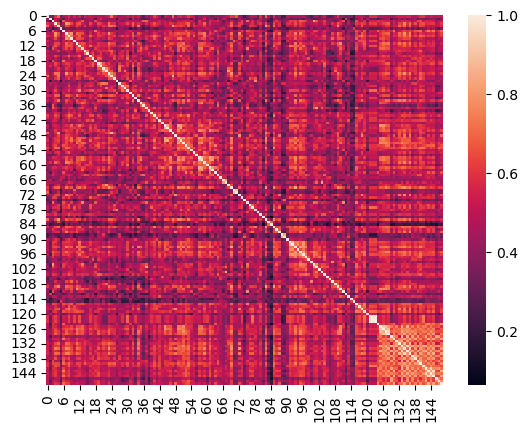

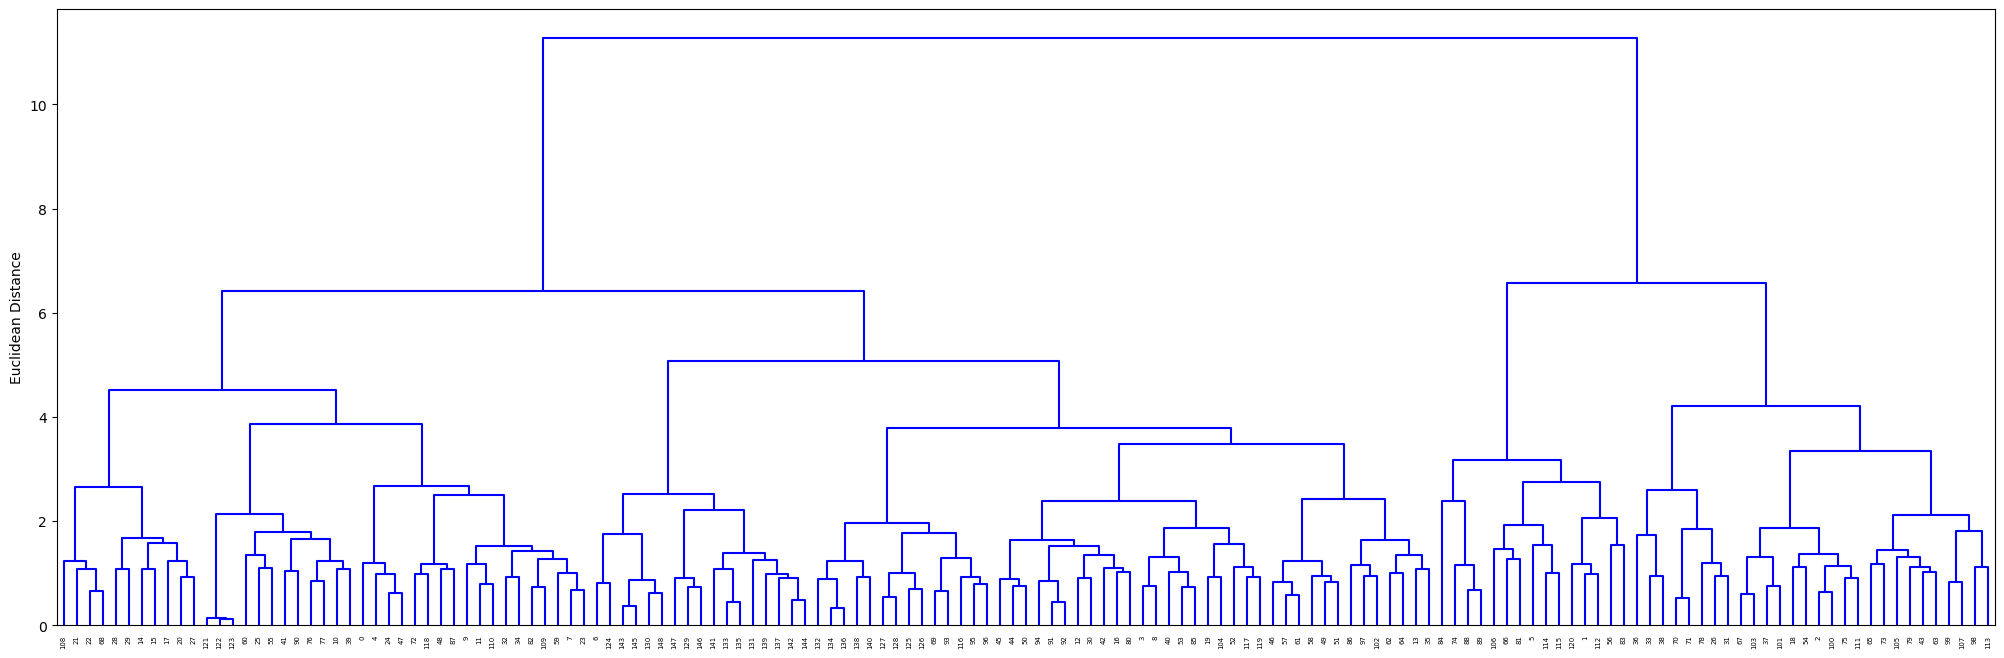

+-----------------------------------+-------------------------------------+----------+
| CBCL                              |                                     |          |
+===================================+=====================================+==========+
| Sentence 1                        | Sentence 2                          | Question |
+-----------------------------------+-------------------------------------+----------+
| 113A. Has other problem           | 113B. Has other problem             | 0.99     |
+-----------------------------------+-------------------------------------+----------+
| 113A. Has other problem           | 113C. Has other problem             | 0.99     |
+-----------------------------------+-------------------------------------+----------+
| 113B. Has other problem           | 113C. Has other problem             | 0.99     |
+-----------------------------------+-------------------------------------+----------+
| Internalizing T Score             | Exter

In [10]:
feature_specs = ['features-Parent_Measures-Demographic_Questionnaire_Measures-Child_Behavior_Checklist-CBCL-spec.json']

# get answers
df_A = item_analysis.get_answers(feature_specs)[0]

# get questions
df_Q = item_analysis.get_questions(feature_specs)[0]

# sentences
sentences = df_Q['Question'].tolist()

# calculate sentence similarity
cosine_scores, pairs = item_analysis.sentence_similarity(sentences)

# plot heatmap
item_analysis.plot_heatmap(array=cosine_scores, labels=None)

# plot dendrogram
item_analysis.dendrogram_plot(dataframe=cosine_scores)

# plot distribution of scores
scores = [r['score'].tolist() for r in pairs]
sns.histplot(scores)
plt.show()

# plot table
item_analysis.plot_top_sentences(pairs, sentences, A_similarity=None, percent=10, title='CBCL')


## TO DO 1

- Repronimschema for HBN (similar to ABCD), this should be a project for an RA (this will make it so much easier to do sentence transformation work)
- add preamble for more context
- tdif similarity - check this comparison with sentenceBert (do the results always form a bellcurve?)
- what kinds of constructs are being evaluated?
- Compare responses across two questionnaires (get correlation distance between two matrices `dcorr`) - number of rows must be the same, but the number of columns can be different
- hierarchical clustering on the cosine similarity matrix (of sentences) to determine whether there are clusters that fall out (look both at sentences and responses, are these clusters in alignment?)
- compare certain "clusters" across questionnaires - anxiety items on CBCL and GAD7 (or anxiety questionnaire). To what extent are they measuring the same construct?
- can we get a correlation across items per participant? rather than focus on the group level zoom in on the individual
- figure: compare parent vs. teacher vs. child predictions


## TO DO 2

- individual level: sign of response between parent + teacher - how do they differ more on subsets of item. do they map onto different clusters of ADHD. is there an item-level breakdown
- part x quesstions: reordr hte rows based on hierarchical clutering (and vice vera), value of matrix - difference between parent and teacher
- compare clinical diagnoses across 

## Compare answer similarities across questionnaires

In [100]:
feature_specs = ['features-Parent_Measures-Demographic_Questionnaire_Measures-Child_Behavior_Checklist-CBCL-spec.json',
                'features-Teacher_Measures-domains-Child_Behavior_Checklist_–_Teacher_Report_Form-TRF-spec.json']

# get answers
df_A = item_analysis.get_answers(feature_specs)

x = df_A[0]; y = df_A[1]


## Calculate distance correlation between two questionnaires (CBCL-Parent and CBCL-Teacher)

In [101]:
dcor.distance_correlation(x, y)

0.31449558403499905

## The distance correlation t-test of independence

In [163]:

dcor.independence.distance_correlation_t_test(x, y)

HypothesisTest(pvalue=0.0, statistic=57.282815452320364)

As we can observe, this test correctly rejects the null hypothesis in the second case and not in the first case.

The test illustrated here is an asymptotic test, that relies in the approximation of the statistic distribution to the Student’s t-distribution under the null hypothesis, when the dimension of the data goes to infinity. This test is thus faster than permutation tests, as it does not require the use of permutations of the data, and it is also deterministic for a given dataset. However, the test should be applied only for high-dimensional data, at least in theory.

We will now plot for the case of normal distributions the histogram of the statistic, and compute the Type I error, as seen in Székely and Rizzo1. Users are encouraged to download this example and increase that number to obtain better estimates of the Type I error. In order to replicate the original results, one should set the value of n_tests to 1000.

## Permutation test of distance correlation

In [ ]:
item_analysis.distance_correlation_permutation(x,y)

## The distance covariance test of independence

In [102]:
random_state = np.random.default_rng(83110)
dcor.independence.distance_covariance_test(
    x,
    y,
    num_resamples=200,
    random_state=random_state,
)

HypothesisTest(pvalue=0.004975124378109453, statistic=213.46578868208118)

We can see that the p-value obtained is indeed very small, and thus we can safely reject the null hypothesis, and consider that there is indeed dependence between the random vectors.

The next test illustrated here is a permutation test, which compares the distance covariance of the original dataset with the one obtained after random permutations of one of the input arrays. Thus, increasing the number of permutations makes the p-value more accurate, but increases the computational cost. 

## Permutation test of distance covariance

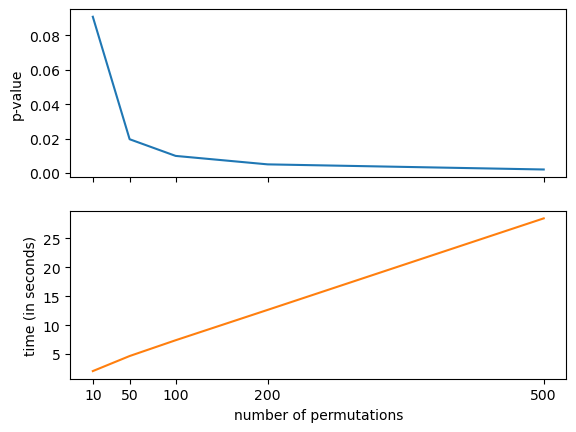

In [156]:
item_analysis.distance_covariance_permutation(x,y)

## Monte Carlo Test - get estimates of Type I error

We generate independent data following a multivariate Gaussian distribution as well as different 
t(v) distributions. In all cases we consider random vectors with dimension 5. We perform the tests for different number of observations, computing the number of permutations used as [200 + 5000/n]. We fix the significance level to 0.1.

In [ ]:
# monte carlo test
#item_analysis.monte_carlo_test(x,y)

## Compare Questionnaires - Answers

Text(0.5, 1.0, 'Language_Tasks')

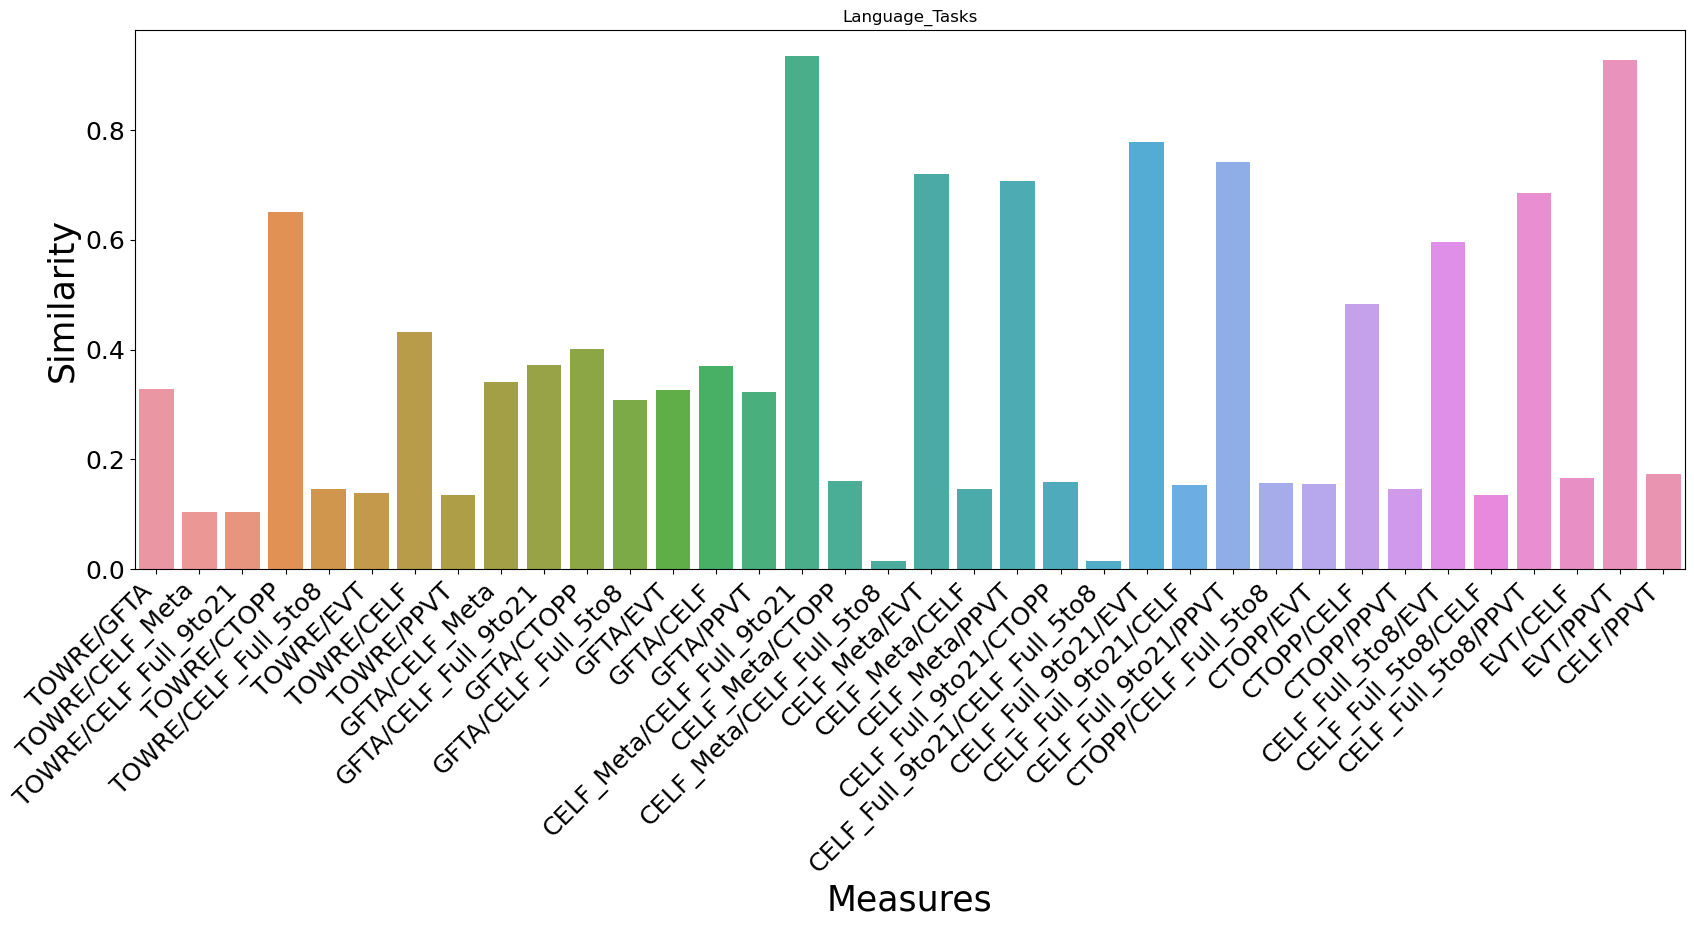

In [103]:
# plot figure 

domain = 'Language_Tasks'
feature_specs = glob.glob(os.path.join(Defaults.FEATURE_DIR, f'*{domain}*'))
    
df = item_analysis.compare_answers(feature_specs)

plt.figure(figsize=(20,7))
sns.barplot(x='measures', y='distance', data=df)
plt.xticks(rotation=45, ha='right');
plt.tick_params(axis='both', which='major', labelsize=18);
plt.xlabel('Measures', fontsize=25)
plt.ylabel('Similarity', fontsize=25);
plt.title(domain)

Text(0.5, 1.0, 'Physical_Fitness')

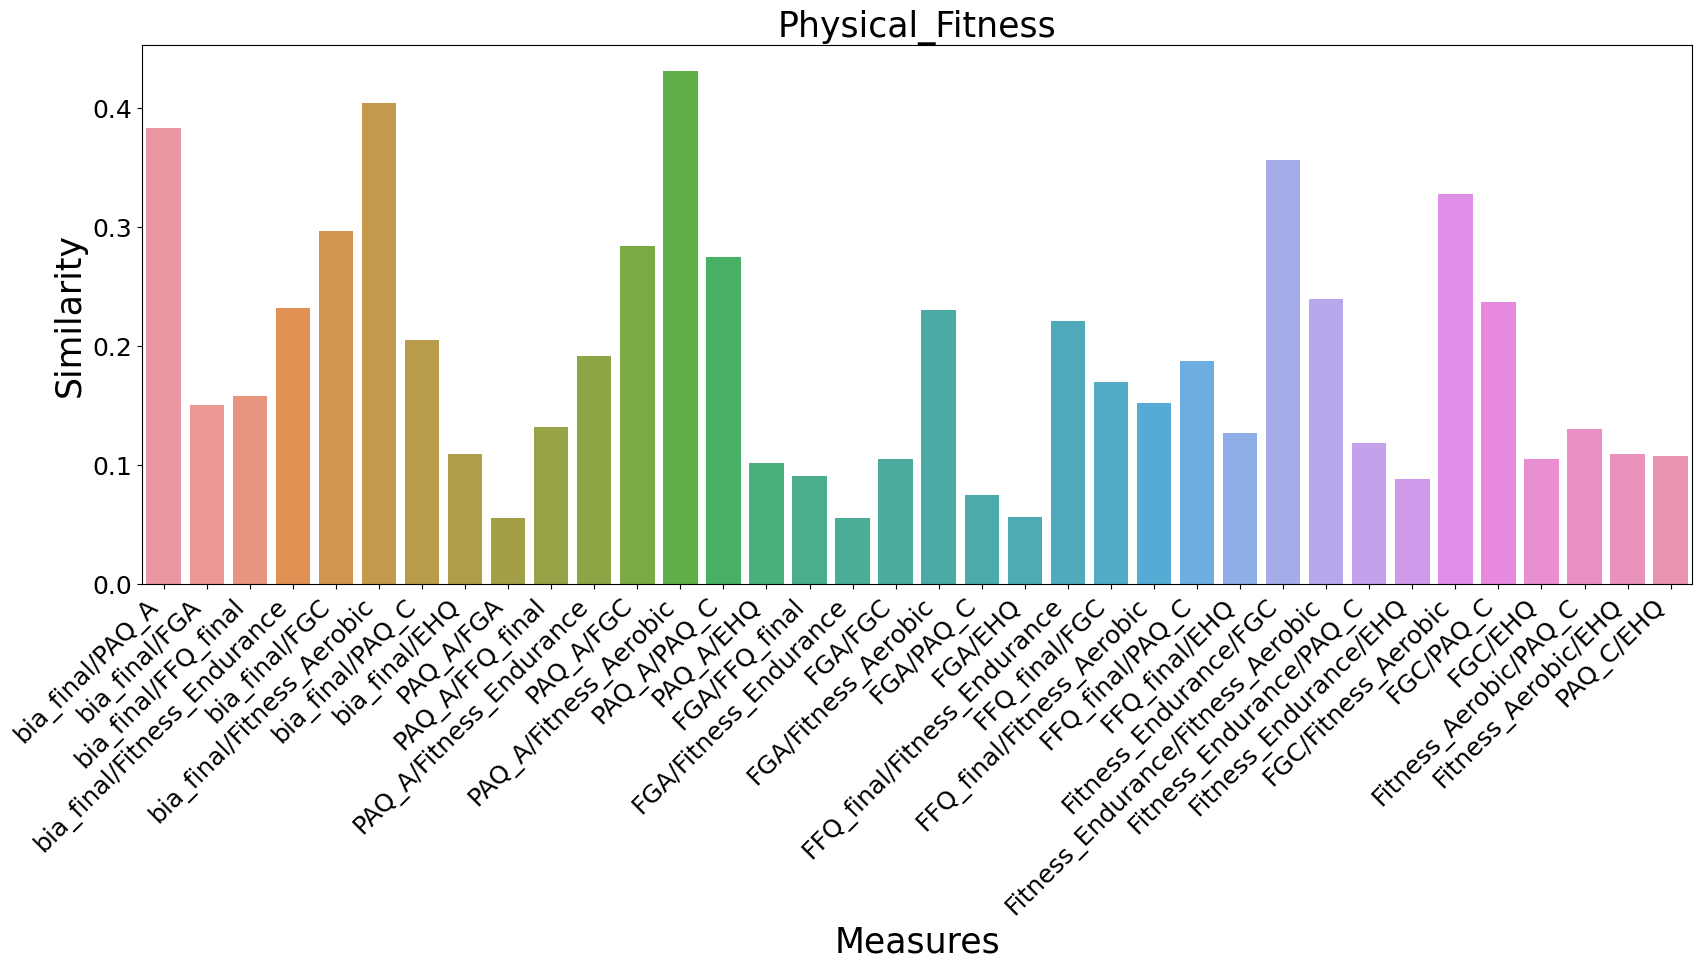

In [235]:
# plot figure 

domain = 'Physical_Fitness'
feature_specs = glob.glob(os.path.join(Defaults.FEATURE_DIR, f'*{domain}*'))
    
df = item_analysis.compare_answers(feature_specs)

plt.figure(figsize=(20,7))
sns.barplot(x='measures', y='distance', data=df)
plt.xticks(rotation=45, ha='right');
plt.tick_params(axis='both', which='major', labelsize=18);
plt.xlabel('Measures', fontsize=25)
plt.ylabel('Similarity', fontsize=25);
plt.title(domain, fontsize=25)

Text(0.5, 1.0, 'Child_Behavior_Checklist')

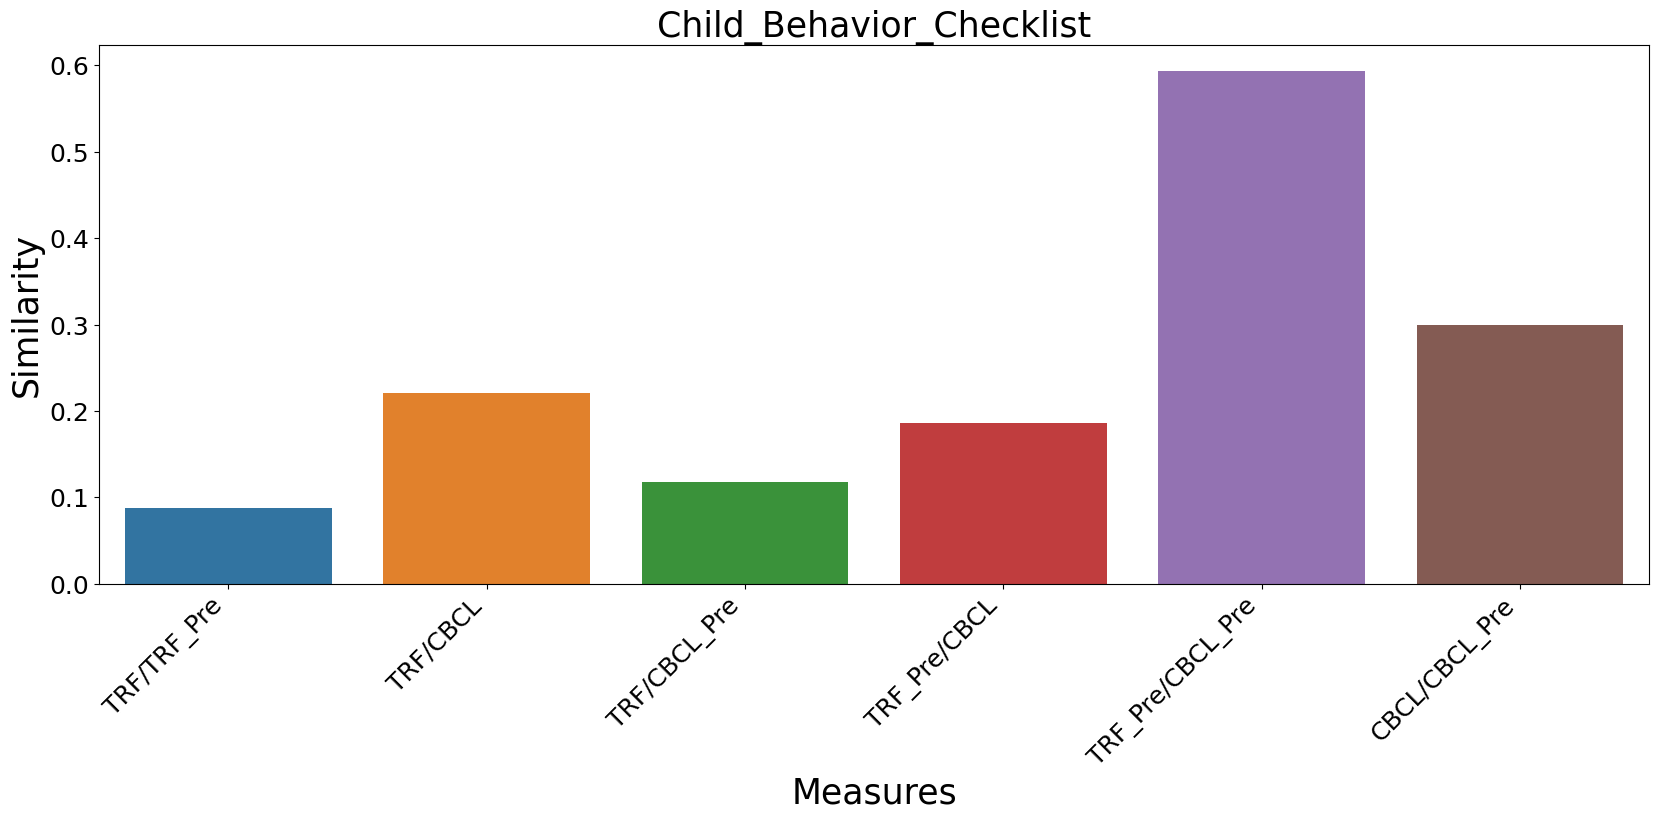

In [234]:
# plot figure 

domain = 'Child_Behavior_Checklist'
feature_specs = glob.glob(os.path.join(Defaults.FEATURE_DIR, f'*{domain}*'))
    
df = item_analysis.compare_answers(feature_specs)

plt.figure(figsize=(20,7))
sns.barplot(x='measures', y='distance', data=df)
plt.xticks(rotation=45, ha='right');
plt.tick_params(axis='both', which='major', labelsize=18);
plt.xlabel('Measures', fontsize=25)
plt.ylabel('Similarity', fontsize=25);
plt.title(domain, fontsize=25)

## compare across age brackets

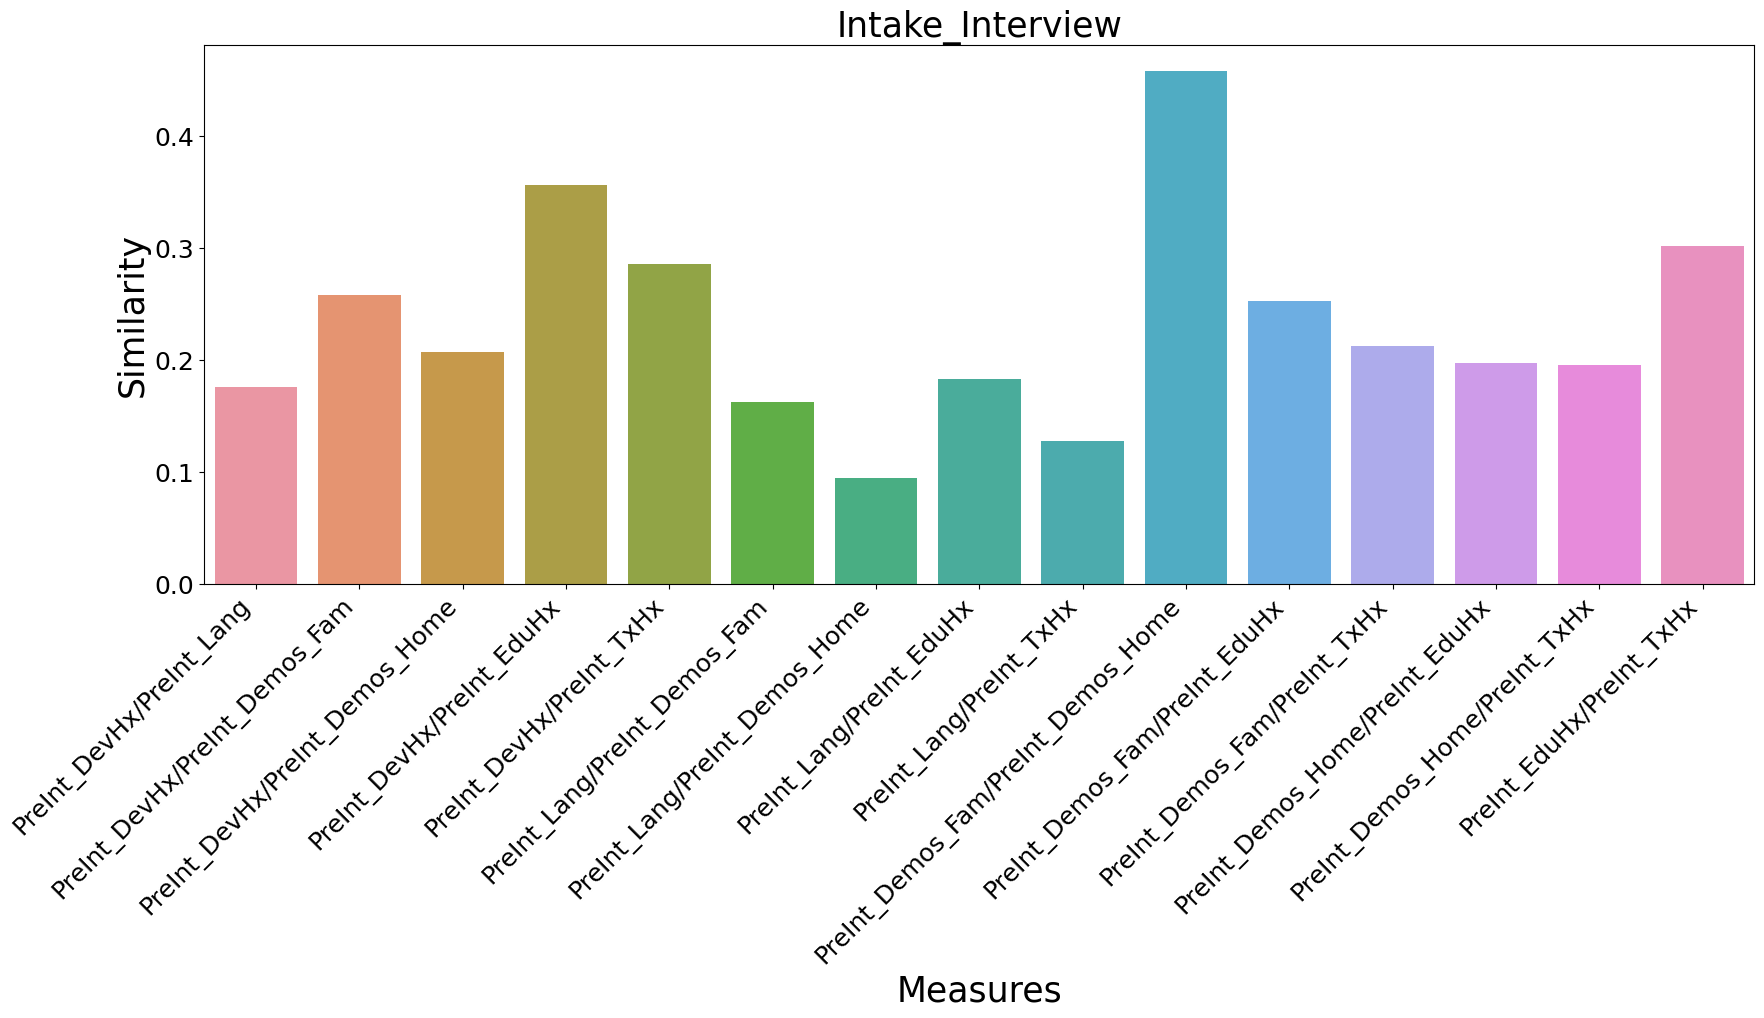

In [240]:
measure = 'Intake_Interview'
feature_specs = glob.glob(os.path.join(Defaults.FEATURE_DIR, f'*{measure}*'))
    
df = item_analysis.compare_answers(feature_specs)

plt.figure(figsize=(20,7))
sns.barplot(x='measures', y='distance', data=df)
plt.xticks(rotation=45, ha='right');
plt.tick_params(axis='both', which='major', labelsize=18);
plt.xlabel('Measures', fontsize=25)
plt.ylabel('Similarity', fontsize=25);
plt.title(measure, fontsize=25);

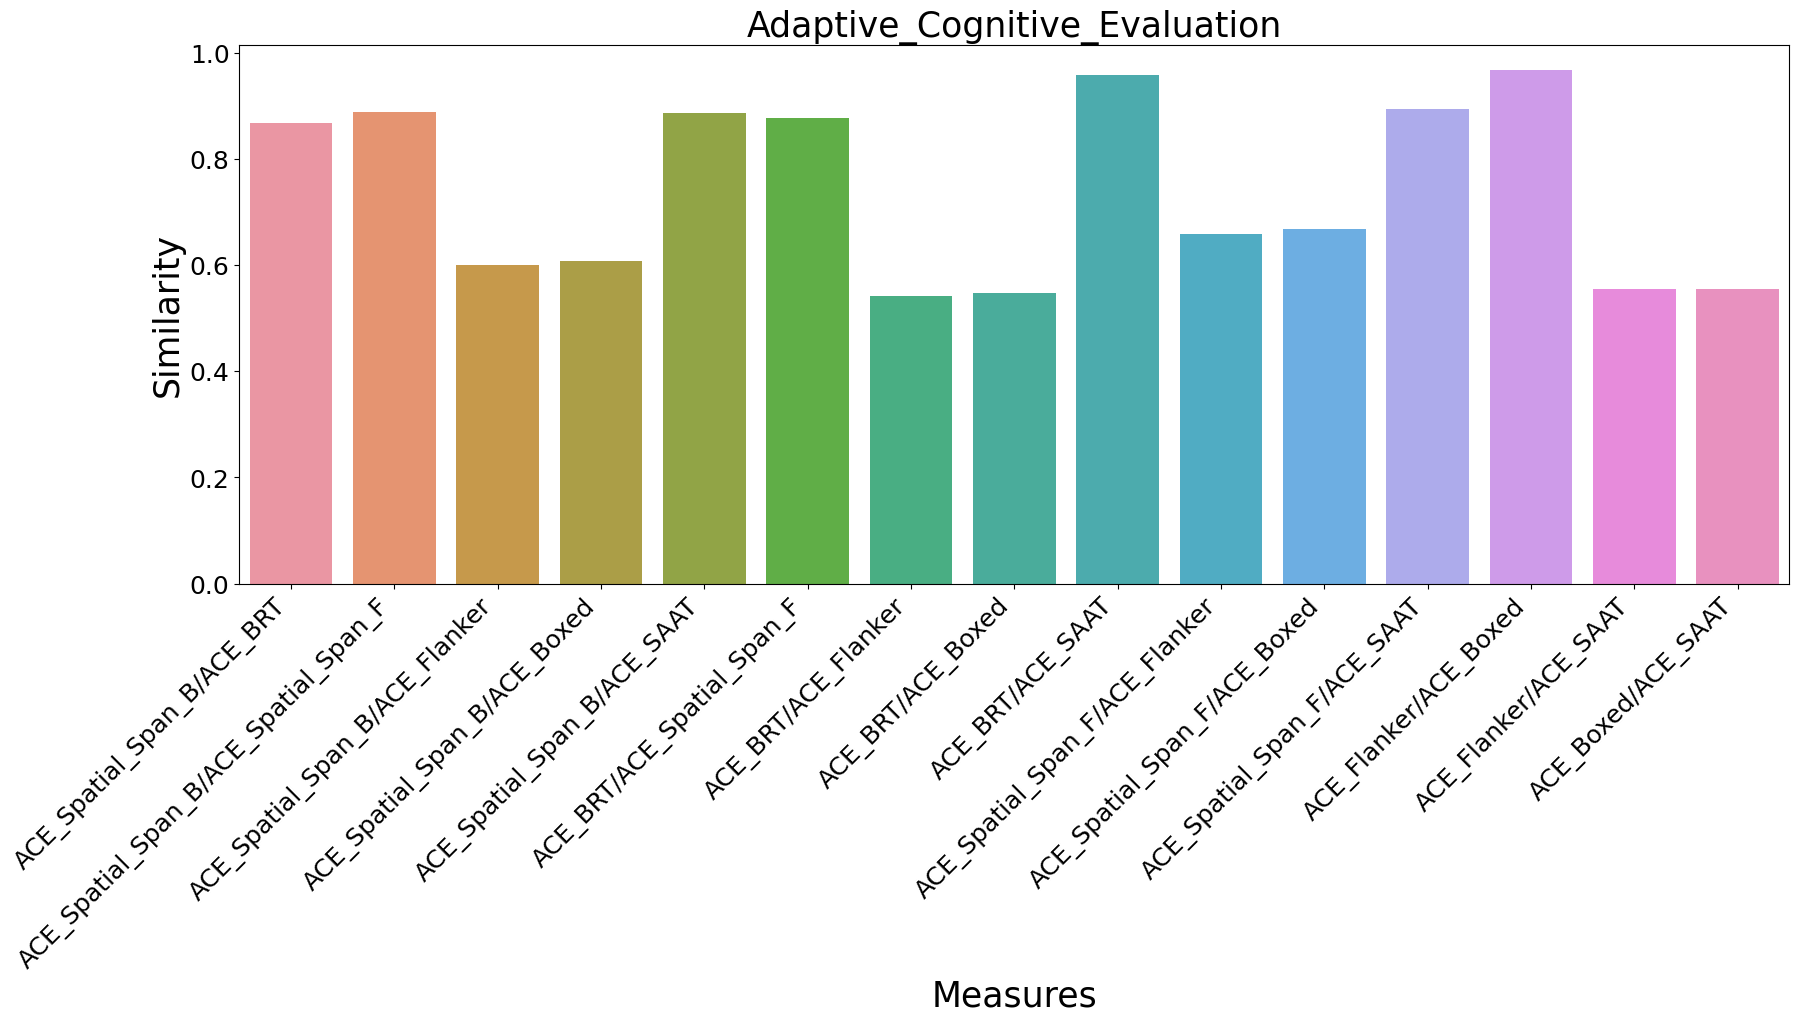

In [241]:
measure = 'Adaptive_Cognitive_Evaluation'
feature_specs = glob.glob(os.path.join(Defaults.FEATURE_DIR, f'*{measure}*'))

df = item_analysis.compare_answers(feature_specs)

plt.figure(figsize=(20,7))
sns.barplot(x='measures', y='distance', data=df)
plt.xticks(rotation=45, ha='right');
plt.tick_params(axis='both', which='major', labelsize=18);
plt.xlabel('Measures', fontsize=25)
plt.ylabel('Similarity', fontsize=25);
plt.title(measure, fontsize=25);

## Compare answers across diagnoses for CBCL (Parent + Teacher)

In [121]:
feature_specs = glob.glob(os.path.join(Defaults.FEATURE_DIR, '*Child_Behavior_Checklist*'))
feature_specs.extend(glob.glob(os.path.join(Defaults.FEATURE_DIR, '*Youth_Self_Report*')))

diagnoses = ['ADHD', 'No_Diagnosis_Given', 'Anxiety_Disorders', 'Depressive_Disorders', 'Autism_Spectrum_Disorder', 'Specific_Learning_Disorder_with_Impairment_in_Reading']

df_all = pd.DataFrame()
for diagnosis in diagnoses:
    df = item_analysis.compare_answers(feature_specs, diagnoses=[diagnosis], split='all')
    df['diagnosis'] = diagnosis
    df_all = pd.concat([df_all, df])
    print(f"adding {diagnosis} to dataframe")


adding ADHD to dataframe
adding No_Diagnosis_Given to dataframe
adding Anxiety_Disorders to dataframe
adding Depressive_Disorders to dataframe
adding Autism_Spectrum_Disorder to dataframe
adding Specific_Learning_Disorder_with_Impairment_in_Reading to dataframe


In [128]:
import plotly.express as px

df = df_all[df_all['measures'].isin(['TRF/CBCL', 'TRF/YSR', 'CBCL/YSR'])] # 'TRF_Pre/CBCL_Pre',
df = df.replace({'TRF/CBCL': 'Teacher/Parent', 
                 'TRF_Pre/CBCL_Pre': 'Teacher (Preschool)/Parent (Preschool)',
                 'TRF/YSR': 'Teacher/Self-Report',
                 'CBCL/YSR': 'Parent/Self-Report'}
               )
df = df.replace({'Anxiety_Disorders': 'Anxiety', 
            'Autism_Spectrum_Disorder': 'ASD', 
            'Specific_Learning_Disorder_with_Impairment_in_Reading': 'Reading Impairment',
            }
          )


fig = px.line_polar(df, r="distances", 
                    theta="diagnosis", 
                    color="measures", 
                    line_close=True, 
                    range_r=[df['distances'].min(), df['distances'].max()]
                   ) 
fig.show()

## Compare answers across ADHD Subtypes for CBCL (Parent + Teacher)

In [326]:
feature_specs = glob.glob(os.path.join(Defaults.FEATURE_DIR, '*Child_Behavior_Checklist*'))
feature_specs.extend(glob.glob(os.path.join(Defaults.FEATURE_DIR, '*Youth_Self_Report*')))

diagnoses = ['ADHD-Combined_Type']

df_all = pd.DataFrame()
for diagnosis in diagnoses:
    df = item_analysis.compare_answers(feature_specs, diagnoses=[diagnosis], split='train')
    df['diagnosis'] = diagnosis
    df_all = pd.concat([df_all, df])
    print(f"adding {diagnosis} to dataframe")
    

KeyError: "None of [Index(['Identifiers'], dtype='object')] are in the [columns]"

In [314]:
import plotly.express as px

df = df_all[df_all['measures'].isin(['TRF/CBCL', 'TRF/YSR', 'CBCL/YSR'])] # 'TRF_Pre/CBCL_Pre',
df = df.replace({'TRF/CBCL': 'Teacher/Parent', 
                 'TRF_Pre/CBCL_Pre': 'Teacher (Preschool)/Parent (Preschool)',
                 'TRF/YSR': 'Teacher/Self-Report',
                 'CBCL/YSR': 'Parent/Self-Report'}
               )

fig = px.line_polar(df, r="distances", 
                    theta="diagnosis", 
                    color="measures", 
                    line_close=True, 
                    range_r=[df['distances'].min(), df['distances'].max()]
                   ) 
fig.show()

In [330]:
feature_specs = glob.glob(os.path.join(Defaults.FEATURE_DIR, '*Child_Behavior_Checklist*'))
feature_specs.extend(glob.glob(os.path.join(Defaults.FEATURE_DIR, '*Youth_Self_Report*')))

diagnoses = ['ADHD-Combined_Type', 'ADHD-Hyperactive_Impulsive_Type', 'ADHD-Inattentive_Type', 'Other_Specified_Attention-Deficit_Hyperactivity_Disorder']

df_all = pd.DataFrame()
for diagnosis in diagnoses:
    for sex in ['male', 'female']:
        df = item_analysis.compare_answers(feature_specs, sex=sex, diagnoses=[diagnosis], split='train')
        df['diagnosis'] = diagnosis
        df['sex'] = sex
        df_all = pd.concat([df_all, df])
        print(f"adding {diagnosis} to dataframe")
    

adding ADHD-Combined_Type to dataframe
adding ADHD-Combined_Type to dataframe
adding ADHD-Hyperactive_Impulsive_Type to dataframe
adding ADHD-Hyperactive_Impulsive_Type to dataframe
adding ADHD-Inattentive_Type to dataframe
adding ADHD-Inattentive_Type to dataframe
adding Other_Specified_Attention-Deficit_Hyperactivity_Disorder to dataframe
adding Other_Specified_Attention-Deficit_Hyperactivity_Disorder to dataframe


In [338]:
import plotly.express as px

df = df_all[df_all['measures'].isin(['TRF/CBCL'])] # 'TRF_Pre/CBCL_Pre',
df = df.replace({'TRF/CBCL': 'Teacher/Parent'}
               )

fig = px.line_polar(df, r="distances", 
                    theta="diagnosis", 
                    color="sex", 
                    line_close=True, 
                    range_r=[df['distances'].min(), df['distances'].max()],
                    title='Teacher/Parent'
                   ) 
fig.show()

In [339]:
import plotly.express as px

df = df_all[df_all['measures'].isin(['TRF/YSR'])] # 'TRF_Pre/CBCL_Pre',
df = df.replace({
                 'TRF/YSR': 'Teacher/Self-Report'
                }
               )

fig = px.line_polar(df, r="distances", 
                    theta="diagnosis", 
                    color="sex", 
                    line_close=True, 
                    range_r=[df['distances'].min(), df['distances'].max()],
                    title='Teacher/Self-Report'
                   ) 
fig.show()

In [340]:
import plotly.express as px

df = df_all[df_all['measures'].isin(['CBCL/YSR'])] # 'TRF_Pre/CBCL_Pre',
df = df.replace({
                 'CBCL/YSR': 'Parent/Self-Report'}
               )

fig = px.line_polar(df, r="distances", 
                    theta="diagnosis", 
                    color="sex", 
                    line_close=True, 
                    range_r=[df['distances'].min(), df['distances'].max()],
                    title='Parent/Self-Report'
                   ) 
fig.show()

## Compare diagnoses across age for CBCL (Parent + Teacher)

### TO DO